# Machine learning: predicting points from environment

**Event-level** data is used (one row per meet × discipline × gender) to predict mean **points** from environmental features. Using points generalizes across events much better than raw time.

**Note:** event identity still matters (different events have different point distributions), but points remove the huge time-scale effect (50s vs 2min). Diagnostics remain to check that the model is not only learning event identity.

**Dependency:** `scikit-learn` (pip install scikit-learn). The package is imported as `sklearn` in Python.

In [39]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "notebooks").exists() else Path.cwd().parent
PROCESSED = PROJECT_ROOT / "data" / "processed"
df = pd.read_csv(PROCESSED / "results_with_environment.csv")
df = df[(df["phase"] == "Finals") & (df["points"].notna())].copy()

# Event-level: one row per (meet_id, discipline_name, gender)
agg = df.groupby(["meet_id", "discipline_name", "gender"], as_index=False).agg(
    points=("points", "mean"),
    n=("points", "count"),
    temperature=("temperature", "first"),
    pressure=("pressure", "first"),
    wbgt=("wbgt", "first"),
    elevation=("elevation", "first"),
    relative_humidity=("relative_humidity", "first"),
    wind_speed=("wind_speed", "first"),
)
agg = agg[agg["n"] >= 3]
print("Event-level rows:", agg.shape[0])

Event-level rows: 526


In [40]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

FEATURES = ["temperature", "pressure", "wbgt", "elevation", "relative_humidity", "wind_speed"]
X_raw = agg[FEATURES].copy()
X_raw["event"] = agg["discipline_name"].astype(str) + "_" + agg["gender"].astype(str)
le = LabelEncoder()
X_raw["event_enc"] = le.fit_transform(X_raw["event"])
X = X_raw[["event_enc"] + FEATURES]
y = agg["points"].values
X = X.fillna(X.median())

# Split by meet: use start_date to get chronological split (last 25% meets = test)
meet_order = agg.groupby("meet_id").agg({"temperature": "first"}).reset_index()
meet_ids = agg["meet_id"].values
np.random.seed(42)
train_meets, test_meets = train_test_split(agg["meet_id"].unique(), test_size=0.25, random_state=42)
train_idx = np.isin(meet_ids, train_meets)
test_idx = np.isin(meet_ids, test_meets)
X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print("Train:", len(y_train), "Test:", len(y_test))

Train: 406 Test: 120


In [41]:
# Ridge
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_s, y_train)
y_pred_r = ridge.predict(X_test_s)
print("Ridge — MAE: {:.4f}, RMSE: {:.4f}, R²: {:.4f}".format(
    mean_absolute_error(y_test, y_pred_r),
    np.sqrt(mean_squared_error(y_test, y_pred_r)),
    r2_score(y_test, y_pred_r)))

# Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)  # no scale needed for RF
y_pred_rf = rf.predict(X_test)
print("Random Forest — MAE: {:.4f}, RMSE: {:.4f}, R²: {:.4f}".format(
    mean_absolute_error(y_test, y_pred_rf),
    np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    r2_score(y_test, y_pred_rf)))

Ridge — MAE: 54.0182, RMSE: 60.6260, R²: -0.2737
Random Forest — MAE: 22.9477, RMSE: 27.0563, R²: 0.7463


## Is the model just using event?

High R² from Random Forest is suspicious: **event type** (e.g. Men's 100m Free vs Women's 200m Back) already determines most of the points. Comparison:
- **Baseline (event only):** predict test mean points by the *training* mean for that event → no env at all.
- **Model with only event:** Ridge/RF on `event_enc` only.
- **Model with only environment:** Ridge/RF on env features only (no event). If R² is near zero, env has little signal when the event is omitted from the model.

In [42]:
# Baseline: predict = mean training time for that event (no env)
train_events = X_train["event_enc"].values
event_mean_train = pd.Series(y_train).groupby(train_events).mean().to_dict()
y_pred_baseline = np.array([event_mean_train.get(e, np.nanmean(y_train)) for e in X_test["event_enc"].values])
r2_baseline = r2_score(y_test, y_pred_baseline)
print("Baseline (event mean only):     R² = {:.4f}".format(r2_baseline))

# Model with ONLY event_enc (no env)
X_train_ev = X_train[["event_enc"]]
X_test_ev = X_test[["event_enc"]]
rf_event_only = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_event_only.fit(X_train_ev, y_train)
r2_event_only = r2_score(y_test, rf_event_only.predict(X_test_ev))
print("RF with event only:            R² = {:.4f}".format(r2_event_only))

# Model with ONLY env (no event) — answers: does env predict points at all without knowing the event?
X_train_env = X_train[FEATURES]
X_test_env = X_test[FEATURES]
scaler_env = StandardScaler()
X_train_env_s = scaler_env.fit_transform(X_train_env.fillna(X_train_env.median()))
X_test_env_s = scaler_env.transform(X_test_env.fillna(X_test_env.median()))
ridge_env_only = Ridge(alpha=1.0, random_state=42)
ridge_env_only.fit(X_train_env_s, y_train)
r2_env_only = r2_score(y_test, ridge_env_only.predict(X_test_env_s))
print("Ridge with env only (no event): R² = {:.4f}".format(r2_env_only))

print("\n→ If baseline/event-only R² ≈ full RF R², the model is effectively just using event.")
print("→ Env-only R² near 0 means environment has little signal without event identity.")

Baseline (event mean only):     R² = 0.0111
RF with event only:            R² = 0.0112
Ridge with env only (no event): R² = -0.2730

→ If baseline/event-only R² ≈ full RF R², the model is effectively just using event.
→ Env-only R² near 0 means environment has little signal without event identity.


**Within-event analysis:** To see if environment actually affects performance, the event is fixed and points are predicted from env only (one point per meet). That removes "event identity" and tests whether e.g. warmer meets have higher/lower points for the same event.

In [43]:
# Within-event: pick one event, predict points from env only (one row per meet)
event_counts = agg.groupby(["discipline_name", "gender"]).size()
pick_event = event_counts[event_counts >= 15].index[0]  # event with ≥15 meets
sub = agg[(agg["discipline_name"] == pick_event[0]) & (agg["gender"] == pick_event[1])].copy()
X_one = sub[FEATURES].fillna(sub[FEATURES].median())
y_one = sub["points"].values
# Simple train/test by meet
meets = sub["meet_id"].unique()
tm, vm = train_test_split(meets, test_size=0.3, random_state=42)
train_m = sub["meet_id"].isin(tm)
X1_train, X1_test = X_one[train_m], X_one[~train_m]
y1_train, y1_test = y_one[train_m], y_one[~train_m]
scaler1 = StandardScaler()
X1_tr_s = scaler1.fit_transform(X1_train)
X1_te_s = scaler1.transform(X1_test)
ridge1 = Ridge(alpha=1.0, random_state=42).fit(X1_tr_s, y1_train)
r2_within = r2_score(y1_test, ridge1.predict(X1_te_s))
print("Event: {} ({})".format(pick_event[0], pick_event[1]))
print("Within-event Ridge (env only), test R² = {:.4f}".format(r2_within))
print("(Positive R² here would mean env explains some variation in points for this event across meets.)")

Event: Men's 100m Backstroke (Men)
Within-event Ridge (env only), test R² = 0.6191
(Positive R² here would mean env explains some variation in points for this event across meets.)


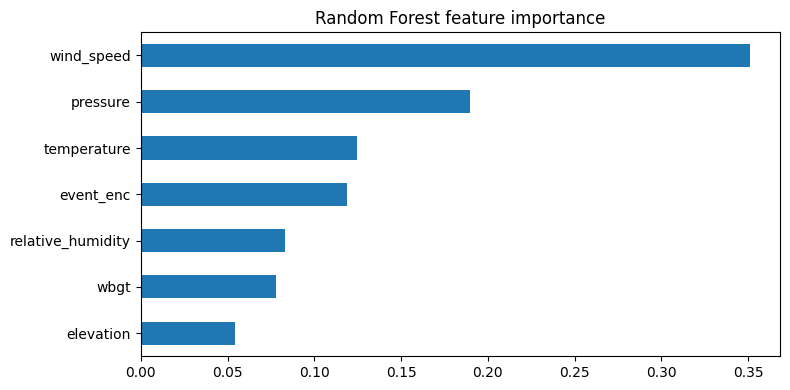

In [44]:
# Feature importance (Random Forest)
feat_names = list(X.columns)
imp = pd.Series(rf.feature_importances_, index=feat_names).sort_values(ascending=True)
imp.plot(kind="barh", figsize=(8, 4), title="Random Forest feature importance")
plt.tight_layout()
plt.show()

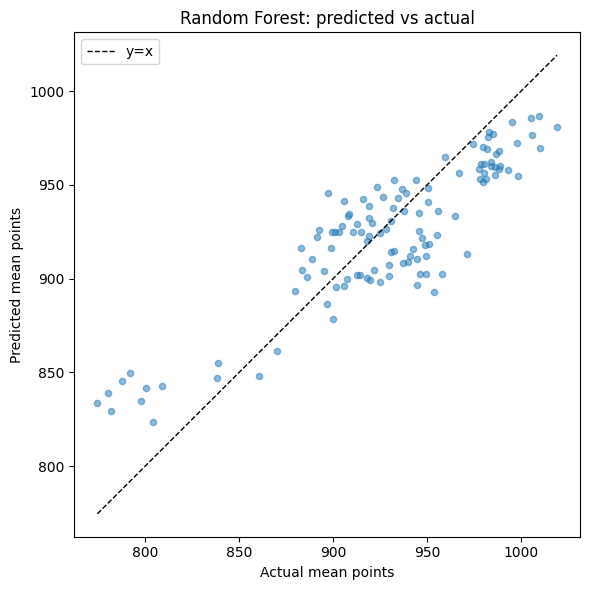

In [45]:
# Predicted vs actual (RF)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_rf, alpha=0.5, s=20)
mn, mx = y_test.min(), y_test.max()
ax.plot([mn, mx], [mn, mx], "k--", lw=1, label="y=x")
ax.set_xlabel("Actual mean points")
ax.set_ylabel("Predicted mean points")
ax.set_title("Random Forest: predicted vs actual")
ax.legend()
plt.tight_layout()
plt.show()

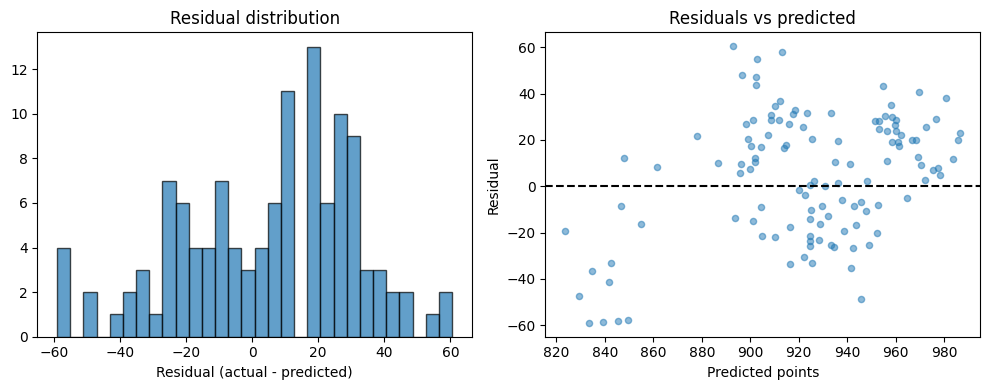

In [46]:
# Residuals
resid = y_test - y_pred_rf
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(resid, bins=30, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Residual (actual - predicted)")
axes[0].set_title("Residual distribution")
axes[1].scatter(y_pred_rf, resid, alpha=0.5, s=20)
axes[1].axhline(0, color="k", linestyle="--")
axes[1].set_xlabel("Predicted points")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs predicted")
plt.tight_layout()
plt.show()